CANEDO_BELTRAN_BRAULIO_P02.ipynb
# Práctica 02 - Nueva prueba médica
Esta TAD tendrá como propósito resolver la problemática de **¿Tiene riesgo de sufrir un derrame cerebral?**. Para ello se creará la Unidad Muestral necesaria y limpiarán las variables necesarias. Tomando en cuenta lo mencionado en la descripción de la tarea se define lo siguinete:
- **Unidad Muestral:** los resultados durante la revisión *"equis"* de alguno de los paceintes.
- **Variable Objetivo ($y$):** tiene riesgo a sufrir un derrame cerebral, sí o no.
- **Valores de la $y$:** el valor de *"0"* para transacciones realizadas por menores a 50; y el valor de *"1"* para transacciones mayores o iguales a 50.

Elementos del código:
- Carga de Datos.
- Limpieza de Datos.
- Análisis exploratorio, tanto discretas/categóricas como continuas.
- Construcción de la TAD.

Indicaciones extras:
- Incluir al menos 3 nuevas variables en ingeniería de variables.
- Incluir la gráfica de tipo hist() de las variables **finales** de la TAD.
- Imprimir la TAD al final del código.

## Descripción (Macro) Variables
Para un entendimiento más sencilla del código y para facilitar la replicabilidad del mismo, se describe en le el apartado presente los términos con los que se nombrarán a tipos de variables y la estructura de las mismas.
- Variables del tipo *letras_*: estas variables contendrán la lista de nombres de variables que se buscan referenciar agrupadas por tipo de variable.
    - *um_*: la(s) variable(s) o combinación que sirve(n) como identificador único para cada registro.
    - *y_*: la variable objetivo que se busca pronosticar.
    - *c_*: todas aquellas variables categóricas que no se pueden sumar, restar, etc, o que sus operaciones matemáticas no tendrían sentido (ejemplo; código postal).
    - *v_*: todas aquellas variables de tipo númerico que indican cantidad de tiempo, dinero, distancia, granos, años, entre otros; con los cuales se pueden realitar operaciones que tienen sentido. 
    - *fh_*: todas las variables que indican un momento en específico en el tiempo y que están en fomrato de fecha y/o hora.
    - *dilit_*: aquellas variables que por alguna razón no se analizarán ni utilizarán.
    - *n_*: variables que han sido normalizadas.
    - *w_*: variables que se les ha asignado un valor numérico en relación con la variable respuesta.
- Prefijos en nombres de las variables: similar a las variables del tipo *letras_*, estas serán utilizadas para mayor facilidad al momento de idetificar lal variable y l amodificación ala cual fue sometida.

# Librerías

In [568]:
%time
# funciones optimización de ciclos
from functools import reduce

# manipulación de datos
import pandas as pd
import numpy as np

# manipulación de sistema
import os

# graficación
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# estadística
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from scipy.stats import ks_2samp
from sklearn.feature_selection import VarianceThreshold
from varclushi import VarClusHi

#
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.impute import SimpleImputer

# escribir parquet
import fastparquet

CPU times: user 5 μs, sys: 1e+03 ns, total: 6 μs
Wall time: 9.06 μs


In [569]:
# Fromato para evitar notación ceintífica
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Importar Datos y Tipo de Datos

In [570]:
ruta = '/home/brauliocb/Documents/Diplomado/01_Modulo/Bases/healthcare.csv'

df = pd.read_csv(ruta)
df.sample(n=10, random_state=787)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3307,3205,Female,79.00,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0
364,71038,Male,34.00,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0
1813,42465,Female,78.00,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0
3352,50434,Male,38.00,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0
4862,49451,Female,53.00,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0
1443,51124,Male,81.00,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0
1563,47893,Male,63.00,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0
3248,41182,Female,35.00,1,0,Yes,Private,Urban,94.20,34.40,smokes,0
4004,54240,Female,30.00,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0
3389,36728,Male,74.00,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0


In [571]:
df.shape

(5110, 12)

In [572]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [573]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [574]:
# revisamos si es necesario que los id, hypertension, heart_disease y stroke es necesario que sean así de grandes
print(f'Valor mínimo de {df['id'].name} es {df['id'].min()}; en cambio el valor máximo es {df['id'].max()}')
print(f'Valor mínimo de {df['hypertension'].name} es {df['hypertension'].min()}; en cambio el valor máximo es {df['hypertension'].max()}')
print(f'Valor mínimo de {df['heart_disease'].name} es {df['heart_disease'].min()}; en cambio el valor máximo es {df['heart_disease'].max()}')
print(f'Valor mínimo de {df['stroke'].name} es {df['stroke'].min()}; en cambio el valor máximo es {df['stroke'].max()}')
print(f'Valor mínimo de {df['age'].name} es {df['age'].min()}; en cambio el valor máximo es {df['age'].max()}')

Valor mínimo de id es 67; en cambio el valor máximo es 72940
Valor mínimo de hypertension es 0; en cambio el valor máximo es 1
Valor mínimo de heart_disease es 0; en cambio el valor máximo es 1
Valor mínimo de stroke es 0; en cambio el valor máximo es 1
Valor mínimo de age es 0.08; en cambio el valor máximo es 82.0


In [575]:
# revismaos solo para comprobar que sea binarias/booleanas las variables
print(f'Valores únicos de {df['hypertension'].name} {df['hypertension'].unique()}')
print(f'Valores únicos de {df['heart_disease'].name} {df['heart_disease'].unique()}')
print(f'Valores únicos de {df['stroke'].name} {df['stroke'].unique()}')

Valores únicos de hypertension [0 1]
Valores únicos de heart_disease [1 0]
Valores únicos de stroke [1 0]


In [576]:
# contamos los números con decimales en age
df['age_int'] = df['age']-df['age'].round()
df[df['age_int']>0]['age'].shape[0], df.shape[0], df[df['age_int']>0]['age'].shape[0]/df.shape[0]


(57, 5110, 0.011154598825831703)

In [577]:
# corroboramos que los id sean valores sin duplicados
len(df['id'].unique()), df.shape[0]

(5110, 5110)

In [578]:
# verificamos que a nivel registro no haya tipos de variables incongruentes
for c in df.columns:
    print(c, df[c].map(type).unique().tolist() )

id [<class 'int'>]
gender [<class 'str'>]
age [<class 'float'>]
hypertension [<class 'int'>]
heart_disease [<class 'int'>]
ever_married [<class 'str'>]
work_type [<class 'str'>]
Residence_type [<class 'str'>]
avg_glucose_level [<class 'float'>]
bmi [<class 'float'>]
smoking_status [<class 'str'>]
stroke [<class 'int'>]
age_int [<class 'float'>]


In [579]:
# para tener conocimiento previo de los nulos, realizamos un conteo por vairbale
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
age_int                0
dtype: int64

## Correcciones Empíricas

In [580]:
# añadimos le nueva edad en meses
df.drop(columns=['age_int'], inplace=True)
df['age_months'] = df['age']*12 
df['age_months'] = np.floor(df['age_months']) # modificar para que redondee al entero anterior
df.rename(columns={'age' : 'age_years'}, inplace=True)
df['age_years'] = np.floor(df['age_years']) # modificar para que redondee al entero anterior

In [581]:
# modificamos hypertension, heart_disease y stroke a vairable s de menos memoria
df['hypertension'] = df['hypertension'].astype('str')
df['heart_disease'] = df['heart_disease'].astype('str')
df['stroke'] = df['stroke'].astype('str')
df['age_years'] = df['age_years'].astype('Int32')
df['age_months'] = df['age_months'].astype('Int32')
df['id'] = df['id'].astype('str')
df.dtypes

id                       str
gender                   str
age_years              Int32
hypertension             str
heart_disease            str
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                   str
age_months             Int32
dtype: object

In [582]:
df.sample(n= 10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888


# Ingeniería de Variables

In [583]:
# indice de años y meses vividos contra  nivel promedio de glucosa
df['idx_agey_glucose'] = df['age_years']/df['avg_glucose_level']
df['idx_agem_glucose'] = df['age_months']/df['avg_glucose_level']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months,idx_agey_glucose,idx_agem_glucose
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948,1.00,12.00
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408,0.25,2.96
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936,1.33,15.96
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456,0.28,3.36
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636,0.63,7.58
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972,1.33,15.91
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756,0.64,7.68
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420,0.37,4.46
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360,0.49,5.87
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888,0.93,11.18


In [584]:
# indice de años y meses vividos contra  nivel promedio de glucosa
df['idx_glucose_agey'] = df['avg_glucose_level']/df['age_years']
df['idx_glucose_agem'] = df['avg_glucose_level']/df['age_months']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948,1.00,12.00,1.00,0.08
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408,0.25,2.96,4.06,0.34
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936,1.33,15.96,0.75,0.06
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456,0.28,3.36,3.57,0.30
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636,0.63,7.58,1.58,0.13
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972,1.33,15.91,0.75,0.06
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756,0.64,7.68,1.56,0.13
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420,0.37,4.46,2.69,0.22
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360,0.49,5.87,2.04,0.17
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888,0.93,11.18,1.07,0.09


In [585]:
# indice de años y meses vividos contra bmi
df['idx_agey_bmi'] = df['age_years']/df['avg_glucose_level']
df['idx_agem_bmi'] = df['age_months']/df['avg_glucose_level']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem,idx_agey_bmi,idx_agem_bmi
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948,1.00,12.00,1.00,0.08,1.00,12.00
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408,0.25,2.96,4.06,0.34,0.25,2.96
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936,1.33,15.96,0.75,0.06,1.33,15.96
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456,0.28,3.36,3.57,0.30,0.28,3.36
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636,0.63,7.58,1.58,0.13,0.63,7.58
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972,1.33,15.91,0.75,0.06,1.33,15.91
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756,0.64,7.68,1.56,0.13,0.64,7.68
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420,0.37,4.46,2.69,0.22,0.37,4.46
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360,0.49,5.87,2.04,0.17,0.49,5.87
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888,0.93,11.18,1.07,0.09,0.93,11.18


In [586]:
# indice de años y meses vividos contra bmi
df['idx_bmi_agey'] = df['bmi']/df['age_years']
df['idx_bmi_agem'] = df['bmi']/df['age_months']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,stroke,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem,idx_agey_bmi,idx_agem_bmi,idx_bmi_agey,idx_bmi_agem
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,...,0,948,1.00,12.00,1.00,0.08,1.00,12.00,0.14,0.01
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,...,0,408,0.25,2.96,4.06,0.34,0.25,2.96,1.03,0.09
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,...,0,936,1.33,15.96,0.75,0.06,1.33,15.96,0.21,0.02
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,...,0,456,0.28,3.36,3.57,0.30,0.28,3.36,0.82,0.07
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,...,0,636,0.63,7.58,1.58,0.13,0.63,7.58,0.69,0.06
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,...,0,972,1.33,15.91,0.75,0.06,1.33,15.91,0.34,0.03
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,...,0,756,0.64,7.68,1.56,0.13,0.64,7.68,0.49,0.04
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,...,0,420,0.37,4.46,2.69,0.22,0.37,4.46,0.98,0.08
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,...,0,360,0.49,5.87,2.04,0.17,0.49,5.87,0.80,0.07
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,...,0,888,0.93,11.18,1.07,0.09,0.93,11.18,0.44,0.04


In [587]:
# indice de bmi entres nivel promedio de glucosa
df['idx_bmi_glucose'] = df['bmi']/df['avg_glucose_level']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem,idx_agey_bmi,idx_agem_bmi,idx_bmi_agey,idx_bmi_agem,idx_bmi_glucose
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,...,948,1.00,12.00,1.00,0.08,1.00,12.00,0.14,0.01,0.14
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,...,408,0.25,2.96,4.06,0.34,0.25,2.96,1.03,0.09,0.25
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,...,936,1.33,15.96,0.75,0.06,1.33,15.96,0.21,0.02,0.28
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,...,456,0.28,3.36,3.57,0.30,0.28,3.36,0.82,0.07,0.23
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,...,636,0.63,7.58,1.58,0.13,0.63,7.58,0.69,0.06,0.44
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,...,972,1.33,15.91,0.75,0.06,1.33,15.91,0.34,0.03,0.45
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,...,756,0.64,7.68,1.56,0.13,0.64,7.68,0.49,0.04,0.31
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,...,420,0.37,4.46,2.69,0.22,0.37,4.46,0.98,0.08,0.37
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,...,360,0.49,5.87,2.04,0.17,0.49,5.87,0.80,0.07,0.39
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,...,888,0.93,11.18,1.07,0.09,0.93,11.18,0.44,0.04,0.41


# Análisis Exploratorio

## Macro Variables

In [588]:
# cambiamos el nombre de la variable stroke que es la vairable objetivo
df.rename(columns={'stroke' : 'y'}, inplace=True)

In [589]:
# Uniad Muestral
um_ = ['id']

# Variable Objetivo
y_ = ['y']

# Variables categóricas
c_ = df.drop(columns=(um_+y_)).select_dtypes(include=['str','object']).columns.tolist()

# Variables numéricas
v_ = df.select_dtypes(include=['Int32','int64','float64','Int8']).columns.tolist()

In [590]:
len(um_)+len(y_)+len(c_)+len(v_), df.shape[1]

(22, 22)

In [591]:
df.rename(columns={c:'v_'+c for c in v_}, inplace=True)
df.rename(columns={c:'c_'+c for c in c_}, inplace=True)

In [592]:
df.sample(n=10, random_state=787)

,id,c_gender,v_age_years,c_hypertension,c_heart_disease,c_ever_married,c_work_type,c_Residence_type,v_avg_glucose_level,v_bmi,...,v_age_months,v_idx_agey_glucose,v_idx_agem_glucose,v_idx_glucose_agey,v_idx_glucose_agem,v_idx_agey_bmi,v_idx_agem_bmi,v_idx_bmi_agey,v_idx_bmi_agem,v_idx_bmi_glucose
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,...,948,1.00,12.00,1.00,0.08,1.00,12.00,0.14,0.01,0.14
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,...,408,0.25,2.96,4.06,0.34,0.25,2.96,1.03,0.09,0.25
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,...,936,1.33,15.96,0.75,0.06,1.33,15.96,0.21,0.02,0.28
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,...,456,0.28,3.36,3.57,0.30,0.28,3.36,0.82,0.07,0.23
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,...,636,0.63,7.58,1.58,0.13,0.63,7.58,0.69,0.06,0.44
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,...,972,1.33,15.91,0.75,0.06,1.33,15.91,0.34,0.03,0.45
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,...,756,0.64,7.68,1.56,0.13,0.64,7.68,0.49,0.04,0.31
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,...,420,0.37,4.46,2.69,0.22,0.37,4.46,0.98,0.08,0.37
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,...,360,0.49,5.87,2.04,0.17,0.49,5.87,0.80,0.07,0.39
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,...,888,0.93,11.18,1.07,0.09,0.93,11.18,0.44,0.04,0.41


In [593]:
c_ = [c for c in  df.columns.tolist() if c.startswith('c_') ]
v_ = [c for c in  df.columns.tolist() if c.startswith('v_') ]

In [594]:
c_

['c_gender',
 'c_hypertension',
 'c_heart_disease',
 'c_ever_married',
 'c_work_type',
 'c_Residence_type',
 'c_smoking_status']

In [595]:
v_

['v_age_years',
 'v_avg_glucose_level',
 'v_bmi',
 'v_age_months',
 'v_idx_agey_glucose',
 'v_idx_agem_glucose',
 'v_idx_glucose_agey',
 'v_idx_glucose_agem',
 'v_idx_agey_bmi',
 'v_idx_agem_bmi',
 'v_idx_bmi_agey',
 'v_idx_bmi_agem',
 'v_idx_bmi_glucose']

## Funciones

In [596]:
def calculo_iv(df , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df.pivot_table( index = v , columns=tgt, values=um[0], aggfunc='count', fill_value=0 )
    aux[ list(range(2)) ] = aux/aux.apply(np.sum)
    aux['w'] = np.log( aux[0] / aux[1] )      ### AQUÍ ESTÁ LA FORMULA DEL WOE #####
    aux['iv'] = (aux[0] - aux[1])*aux['w']

    return v, aux['iv'].sum()

def clasificacion_woe(df , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df.pivot_table( index = v ,
                          columns=tgt,
                         values=um[0],
                         aggfunc='count',
                         fill_value=0 )

    aux[ list(range(2)) ] = aux/aux.apply(np.sum)

    aux['w'] = np.log( aux[0] / aux[1] ) ### AQUÍ ESTÁ LA FORMULA DEL WOE #####

    aux.drop(range(2),axis=1,inplace=True)

    aux = aux.to_dict()['w']

    return v, aux

def freq(df, var):
    if type(var) != list:
        var = [var]
    for v in var:
        #v = 'state'
        aux = df[v].value_counts().to_frame().rename(columns={'count':'FA'})
        aux['FR'] = aux['FA'] / aux['FA'].sum()
        aux[['FAA','FRA']] = aux.apply(  np.cumsum )
        print(f"La variable: {v}")
        display(aux)
        print("\n")

def normalizar(df, v, umbral):
    #umbral = 0.03 # 0.05
    aux = df[v].value_counts(True).to_frame()
    aux[f"n_{v}"] = np.where( aux['proportion'] < umbral , 'CAT_PEQUE' ,aux.index )

    moda  = aux.head()[f'n_{v}'].values[0]

    if aux.loc[ aux[f'n_{v}'] == 'CAT_PEQUE' ]['proportion'].sum() < umbral:
        aux[f'n_{v}'].replace({'CAT_PEQUE':moda},inplace=True)

    aux.reset_index(inplace=True)

    return df.merge( aux , left_on=[v] , right_on=[v] , how='inner' ).drop('proportion',axis=1)

def discretizar(df_aux, v, k):

    kb = KBinsDiscretizer(n_bins=k, encode='ordinal', strategy='quantile', subsample=None)
    df_aux = df_aux.copy()

    # Asegurar que no haya valores NaN antes de discretizar
    df_aux[v] = pd.to_numeric(df_aux[v], errors='coerce')
    df_aux = df_aux.dropna(subset=[v])

    # Ajustar el discretizador
    kb.fit(df_aux[[v]])

    # Obtener los intervalos como strings usando pd.cut()
    bins = kb.bin_edges_[0]  # Extraer los límites de los bins
    df_aux[f'd_{v}_{k}'] = pd.cut(df_aux[v], bins=bins, include_lowest=True).astype(str)

    return df_aux

## Categóricas/Discretas

In [597]:
for i in c_:
    print(f'{df[i].value_counts(True, dropna=False) * 100 }\n')

c_gender
Female   58.59
Male     41.39
Other     0.02
Name: proportion, dtype: float64

c_hypertension
0   90.25
1    9.75
Name: proportion, dtype: float64

c_heart_disease
0   94.60
1    5.40
Name: proportion, dtype: float64

c_ever_married
Yes   65.62
No    34.38
Name: proportion, dtype: float64

c_work_type
Private         57.24
Self-employed   16.03
children        13.44
Govt_job        12.86
Never_worked     0.43
Name: proportion, dtype: float64

c_Residence_type
Urban   50.80
Rural   49.20
Name: proportion, dtype: float64

c_smoking_status
never smoked      37.03
Unknown           30.22
formerly smoked   17.32
smokes            15.44
Name: proportion, dtype: float64



Debido a que en la categorías casi no están tan pulverizadas no se va a normalizar para crear/unir otros en una variable aparte. En los casos en los que hay con muy pocos registros, solo es una de las opciones, por lo que se asume que esa opción es el *otro*.

In [598]:
(df[y_].value_counts()/df.shape[0])*100

y
0   95.13
1    4.87
Name: count, dtype: float64

Cabe hacer hincapié que por si sola la variable objetivo tiene muy pocos resgistros en donde ocurre el evento (por un lado qeu bueno porque son infartos), pero podría complicar el análisis al momento de revisar las variables unarias.

## Numércias/Continuas

In [599]:
df[v_].shape

(5110, 13)

### Valores Ausentes

In [600]:
df[v_].isna().sum()

v_age_years              0
v_avg_glucose_level      0
v_bmi                  201
v_age_months             0
v_idx_agey_glucose       0
v_idx_agem_glucose       0
v_idx_glucose_agey       0
v_idx_glucose_agem       0
v_idx_agey_bmi           0
v_idx_agem_bmi           0
v_idx_bmi_agey         201
v_idx_bmi_agem         201
v_idx_bmi_glucose      201
dtype: int64

Aún se ceunta con varias registros de las variables creadas a partir de la variable **bmi**; mas adelante se realizará imputación y se verificará si la distribución de la variables se modifica.

### Análisis Univariado (por variable)

In [601]:
df[v_].describe(percentiles=np.arange(0,1.01,0.1))

/home/brauliocb/Documents/Diplomado/01_Modulo/pyenv_mod1/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/home/brauliocb/Documents/Diplomado/01_Modulo/pyenv_mod1/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/home/brauliocb/Documents/Diplomado/01_Modulo/pyenv_mod1/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/home/brauliocb/Documents/Diplomado/01_Modulo/pyenv_mod1/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


,v_age_years,v_avg_glucose_level,v_bmi,v_age_months,v_idx_agey_glucose,v_idx_agem_glucose,v_idx_glucose_agey,v_idx_glucose_agem,v_idx_agey_bmi,v_idx_agem_bmi,v_idx_bmi_agey,v_idx_bmi_agem,v_idx_bmi_glucose
count,5110.00,5110.00,4909.00,5110.00,5110.00,5110.00,5110.00,5110.00,5110.00,5110.00,4909.00,4909.00,4909.00
mean,43.22,106.15,28.89,518.70,0.45,5.42,inf,inf,0.45,5.42,inf,inf,0.31
std,22.63,45.28,7.85,271.38,0.28,3.37,<NA>,<NA>,0.28,3.37,<NA>,<NA>,0.13
min,0.00,55.12,10.30,0.00,0.00,0.00,0.69,0.06,0.00,0.00,0.14,0.01,0.06
0%,0.00,55.12,10.30,0.00,0.00,0.00,0.69,0.06,0.00,0.00,0.14,0.01,0.06
10%,11.00,65.79,19.70,132.00,0.11,1.30,1.19,0.10,0.11,1.30,0.38,0.03,0.16
20%,20.00,73.76,22.50,240.00,0.21,2.50,1.45,0.12,0.21,2.50,0.46,0.04,0.20
30%,30.00,80.04,24.50,360.00,0.28,3.33,1.73,0.14,0.28,3.33,0.53,0.04,0.23
40%,38.00,85.60,26.40,456.00,0.34,4.07,2.07,0.17,0.34,4.07,0.60,0.05,0.26
50%,45.00,91.88,28.10,540.00,0.40,4.85,2.48,0.21,0.40,4.85,0.70,0.06,0.29


In [602]:
# por los valores infinitos no es posible graficar
#df[v_].hist(
#    color='#008080',
#    grid=False
#)

### Imputación
La imputación se llevara a acabo tanto en valores Na como en valores infinitos.

In [603]:
df[v_] = df[v_].replace([np.inf,-np.inf], np.nan)

df[v_]

,v_age_years,v_avg_glucose_level,v_bmi,v_age_months,v_idx_agey_glucose,v_idx_agem_glucose,v_idx_glucose_agey,v_idx_glucose_agem,v_idx_agey_bmi,v_idx_agem_bmi,v_idx_bmi_agey,v_idx_bmi_agem,v_idx_bmi_glucose
0,67,228.69,36.60,804,0.29,3.52,3.41,0.28,0.29,3.52,0.55,0.05,0.16
1,61,202.21,NaN,732,0.30,3.62,3.31,0.28,0.30,3.62,<NA>,<NA>,NaN
2,80,105.92,32.50,960,0.76,9.06,1.32,0.11,0.76,9.06,0.41,0.03,0.31
3,49,171.23,34.40,588,0.29,3.43,3.49,0.29,0.29,3.43,0.70,0.06,0.20
4,79,174.12,24.00,948,0.45,5.44,2.20,0.18,0.45,5.44,0.30,0.03,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,80,83.75,NaN,960,0.96,11.46,1.05,0.09,0.96,11.46,<NA>,<NA>,NaN
5106,81,125.20,40.00,972,0.65,7.76,1.55,0.13,0.65,7.76,0.49,0.04,0.32
5107,35,82.99,30.60,420,0.42,5.06,2.37,0.20,0.42,5.06,0.87,0.07,0.37
5108,51,166.29,25.60,612,0.31,3.68,3.26,0.27,0.31,3.68,0.50,0.04,0.15


In [604]:
# asignamos la función Simple Imputer
im = SimpleImputer(strategy='median')

In [605]:
im.fit(df[v_])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['v_age_years','v_avg_glucose_level','v_bmi',...,'v_idx_bmi_agey', 'v_idx_bmi_agem','v_idx_bmi_glucose']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](13,)","[45. ,91.88,28.1 ,..., 0.7 , 0.06, 0.29]"


In [606]:
df[v_] = im.transform(df[v_])

df[v_].isna().sum()

v_age_years            0
v_avg_glucose_level    0
v_bmi                  0
v_age_months           0
v_idx_agey_glucose     0
v_idx_agem_glucose     0
v_idx_glucose_agey     0
v_idx_glucose_agem     0
v_idx_agey_bmi         0
v_idx_agem_bmi         0
v_idx_bmi_agey         0
v_idx_bmi_agem         0
v_idx_bmi_glucose      0
dtype: int64

#### Distribuciones Alteradas 

In [607]:
df_ks = pd.DataFrame( map( lambda x: ( x , ks_2samp( df[x].dropna() , df[v_][x] ).statistic ) , v_  ) , columns = ['var','ks']   )

# Si el factor ks > 0.1 , la variable esta "rota" ( se alteró la distribución )
df_ks

,var,ks
0,v_age_years,0.00
1,v_avg_glucose_level,0.00
2,v_bmi,0.00
3,v_age_months,0.00
4,v_idx_agey_glucose,0.00
5,v_idx_agem_glucose,0.00
6,v_idx_glucose_agey,0.00
7,v_idx_glucose_agem,0.00
8,v_idx_agey_bmi,0.00
9,v_idx_agem_bmi,0.00


### Varianza

In [608]:
vt = VarianceThreshold(threshold=1.0)

vt.fit(df[v_])

sin_varianza = [ v for v, u in zip(v_ , vt.get_support() ) if not(u) ]

sin_varianza

['v_idx_agey_glucose', 'v_idx_agey_bmi', 'v_idx_bmi_agem', 'v_idx_bmi_glucose']

Las variables geenradasa fueron las resultantes en ser consideradas sin varianza. Analizamos el comportamiento de dichas variables.

array([[<Axes: title={'center': 'v_idx_agey_glucose'}>,
        <Axes: title={'center': 'v_idx_agey_bmi'}>],
       [<Axes: title={'center': 'v_idx_bmi_agem'}>,
        <Axes: title={'center': 'v_idx_bmi_glucose'}>]], dtype=object)

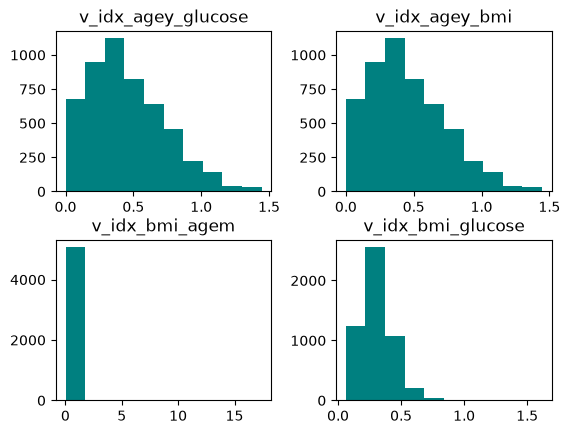

In [609]:
df[sin_varianza].hist(
    color='#008080',
    grid=False
)

In [610]:
v_ = [i for i in v_ if i not in sin_varianza]

v_

['v_age_years',
 'v_avg_glucose_level',
 'v_bmi',
 'v_age_months',
 'v_idx_agem_glucose',
 'v_idx_glucose_agey',
 'v_idx_glucose_agem',
 'v_idx_agem_bmi',
 'v_idx_bmi_agey']

### Valores Extremos

In [611]:
ext = df[v_].describe( percentiles=[.01,.99] ).T[['1%','99%']].reset_index()

for v, li, ls in ext.values:
    df[f'ol_{v}'] = (( df[v] < li ) | ( df[v] > ls )).astype(int)

df['ext'] = df.filter(like='ol_').max(axis=1)

df.drop(df.filter(like='ol_').columns, axis=1, inplace=True)

df['ext'].value_counts(True)*100

ext
0   92.43
1    7.57
Name: proportion, dtype: float64

In [612]:
df['ext'].value_counts()

ext
0    4723
1     387
Name: count, dtype: int64

In [613]:
# Selecciono los que NO son extremos o Eliminar extremos
df = df.loc[df['ext'] == 0].reset_index(drop=True).drop(['ext'],axis=1)

df.shape

(4723, 22)

### Análisis Bivariado

In [614]:
df[v_].corr()

,v_age_years,v_avg_glucose_level,v_bmi,v_age_months,v_idx_agem_glucose,v_idx_glucose_agey,v_idx_glucose_agem,v_idx_agem_bmi,v_idx_bmi_agey
v_age_years,1.00,0.25,0.34,1.00,0.77,-0.55,-0.56,0.77,-0.59
v_avg_glucose_level,0.25,1.00,0.17,0.25,-0.37,0.04,0.05,-0.37,-0.11
v_bmi,0.34,0.17,1.00,0.33,0.22,-0.33,-0.34,0.22,-0.23
v_age_months,1.00,0.25,0.33,1.00,0.77,-0.55,-0.56,0.77,-0.59
v_idx_agem_glucose,0.77,-0.37,0.22,0.77,1.00,-0.53,-0.54,1.00,-0.49
v_idx_glucose_agey,-0.55,0.04,-0.33,-0.55,-0.53,1.00,0.99,-0.53,0.89
v_idx_glucose_agem,-0.56,0.05,-0.34,-0.56,-0.54,0.99,1.00,-0.54,0.89
v_idx_agem_bmi,0.77,-0.37,0.22,0.77,1.00,-0.53,-0.54,1.00,-0.49
v_idx_bmi_agey,-0.59,-0.11,-0.23,-0.59,-0.49,0.89,0.89,-0.49,1.00


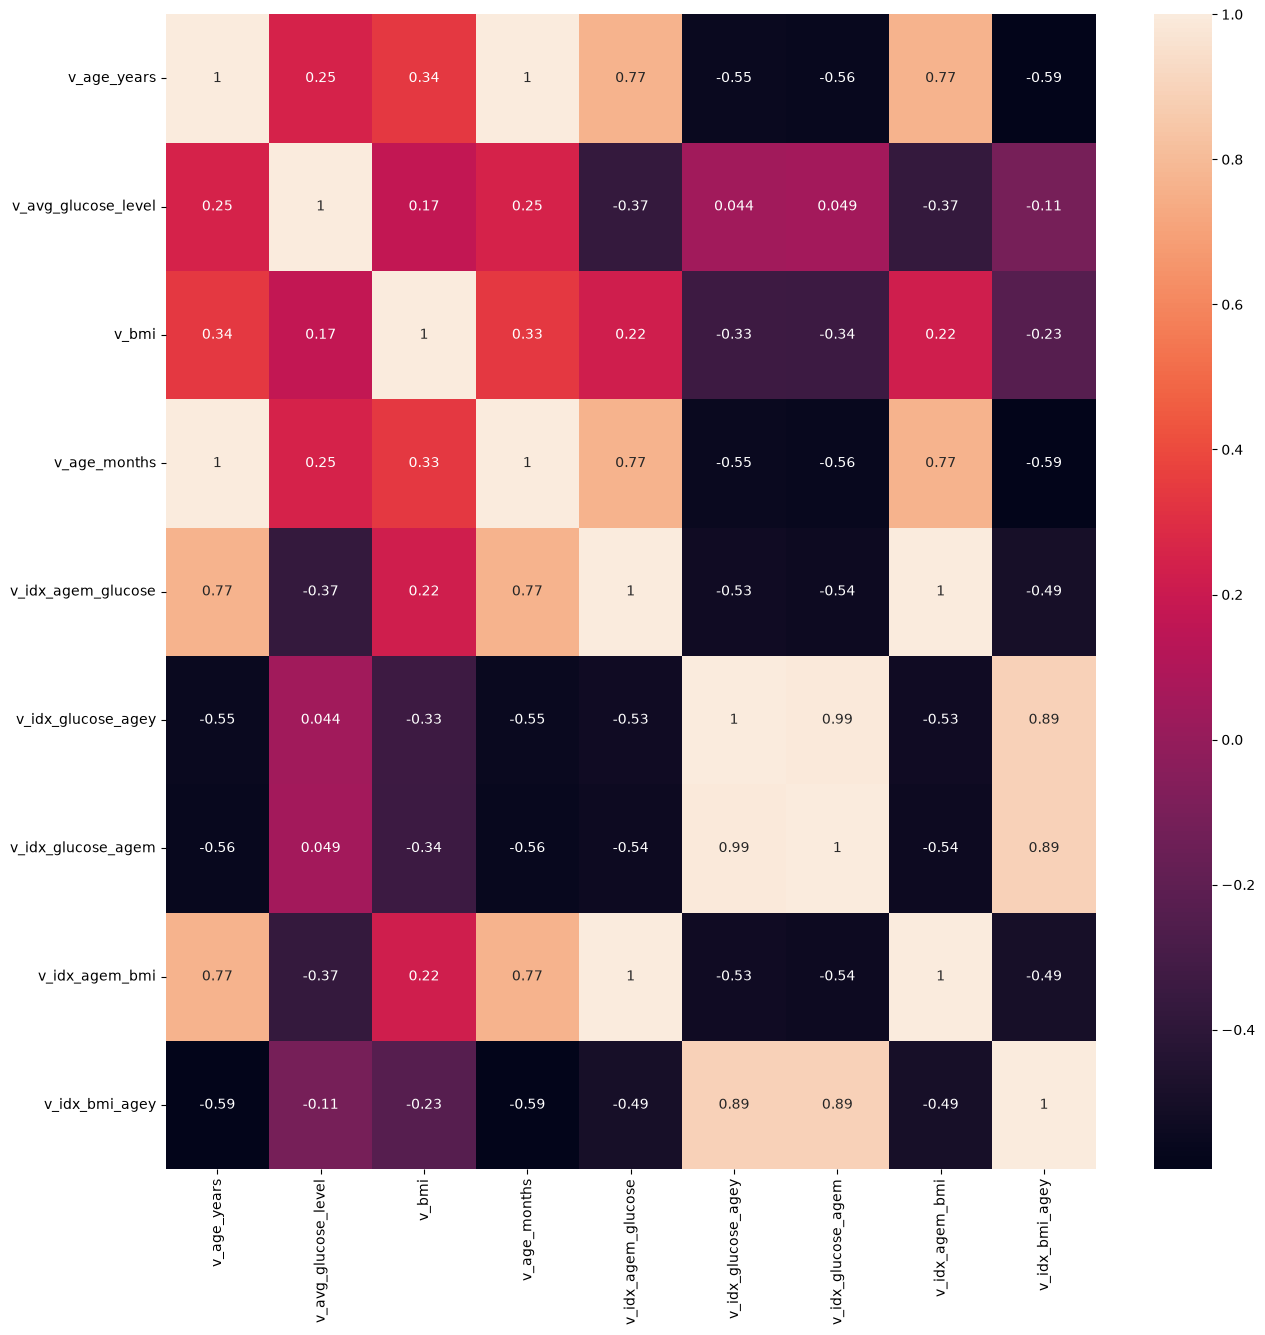

In [615]:
corr_df = df[v_].corr()
plt.figure(figsize=(15,15))
sns.heatmap( corr_df , annot=True )
plt.show()

Hay varias variables que entre sí tienen un valor positivo alto de correlación, principalmente entre las variaciones de índices que se generaron. Lo cual tiene sentido pues son la misma información pero con transformaciones lineales.

In [616]:
# definimos las varibales e interes para analizar a profundidad
lst_var_corrs_interes = [
    'v_idx_agem_glucose',
    'v_age_years',
    'v_age_months',
    'v_idx_glucose_agey',
    'v_idx_glucose_agem',
    'v_idx_bmi_agey',
    'v_idx_agem_bmi'
]

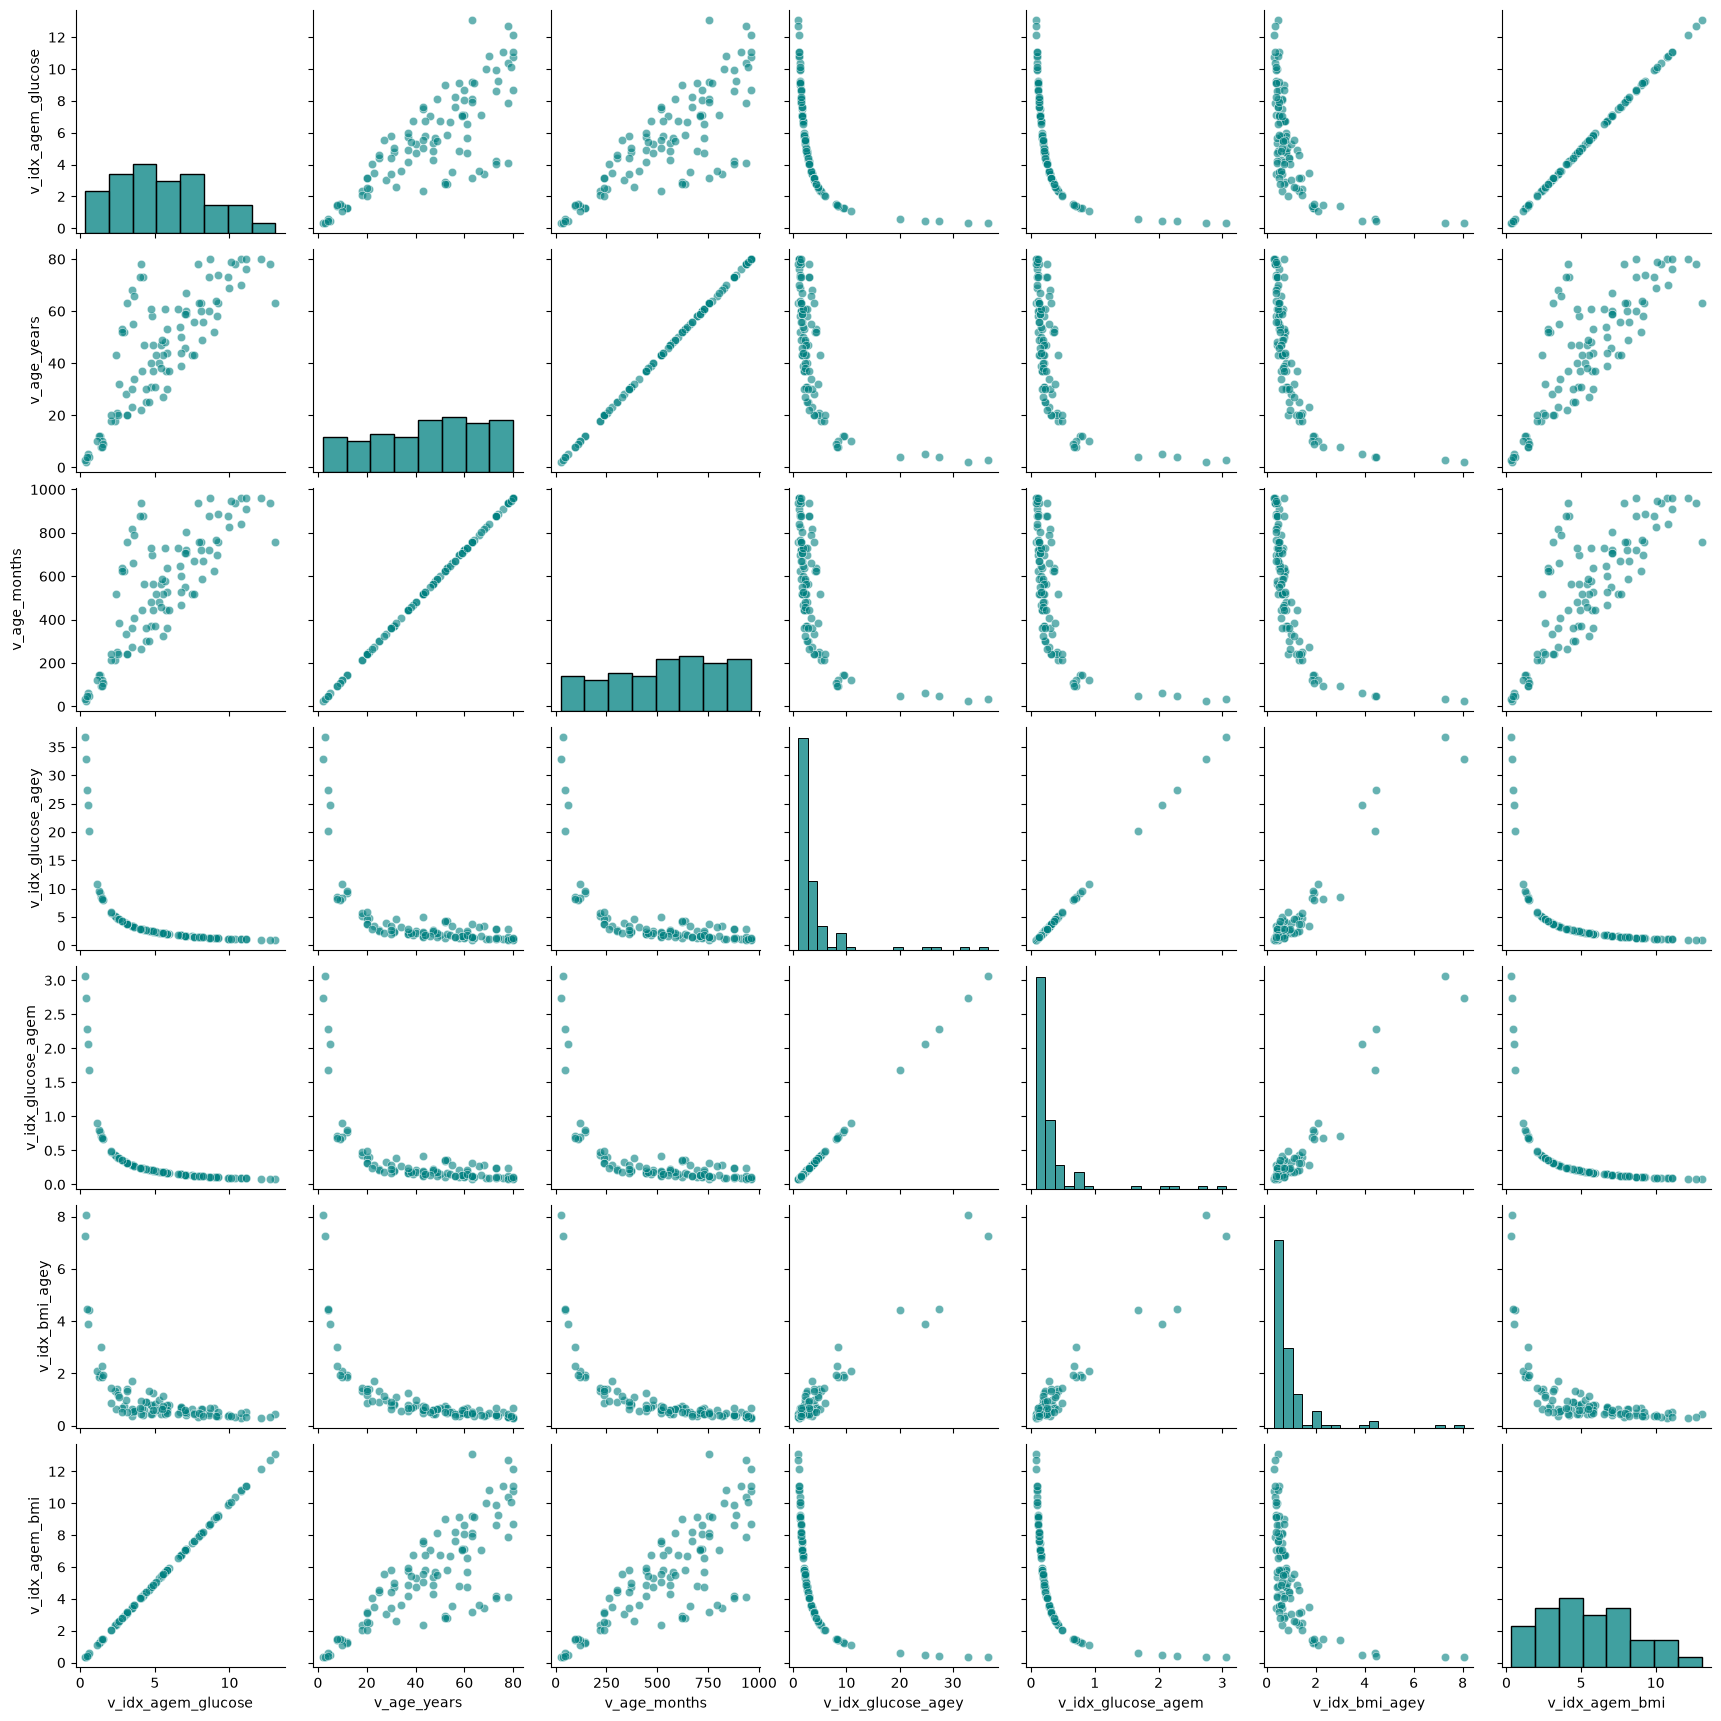

In [617]:
# siempre graficar esto con una muestra
sns.pairplot(df[lst_var_corrs_interes].sample(100, random_state=787),
             plot_kws={'color': '#008080', 'alpha': 0.6},
             diag_kws={'color': '#008080', 'fill': True}
             )

Aparte de haber claras funciones marcadas que relacionan varias variables, llama la atención que algunas de ellas parecen tener relaciones heterocedasticas (varianza no aleatoria y cresciente con el tiempo), lo cual complicará al momento de aplicar cualquier modelo, por ello se recomienda evitar estas variables con dichas relaciones. El análisis con la función **VarClusHi** ayudará a decidir las variables que retirar.

### Multicolinealidad

In [618]:
vc = VarClusHi(df=df[v_], feat_list=v_)

vc.varclus()

In [619]:
rs = vc.rsquare
rs = rs.sort_values( by = ['Cluster','RS_Ratio'] ,ascending=[1,1] ).reset_index(drop=True)
rs['id'] = rs.groupby('Cluster').cumcount() + 1
rs

,Cluster,Variable,RS_Own,RS_NC,RS_Ratio,id
0,0,v_idx_agem_glucose,0.88,0.28,0.16,1
1,0,v_idx_agem_bmi,0.88,0.28,0.16,2
2,0,v_age_months,0.88,0.34,0.18,3
3,0,v_age_years,0.88,0.34,0.18,4
4,1,v_avg_glucose_level,0.58,0.00,0.42,1
5,1,v_bmi,0.58,0.10,0.46,2
6,2,v_idx_glucose_agey,0.97,0.33,0.04,1
7,2,v_idx_glucose_agem,0.97,0.34,0.04,2
8,2,v_idx_bmi_agey,0.90,0.33,0.15,3


Tomando en cuenta el resultado de obtenido se recomienda en l literatura escoger variables equilibradas entre $R^2$ _own_cluster y $R^2$ _nearest_cluster.

In [620]:
v_ = rs.loc[ rs['id'] == 1  ]['Variable'].tolist()

len(v_), v_

(3, ['v_idx_agem_glucose', 'v_avg_glucose_level', 'v_idx_glucose_agey'])

array([[<Axes: title={'center': 'v_idx_agem_glucose'}>,
        <Axes: title={'center': 'v_avg_glucose_level'}>],
       [<Axes: title={'center': 'v_idx_glucose_agey'}>, <Axes: >]],
      dtype=object)

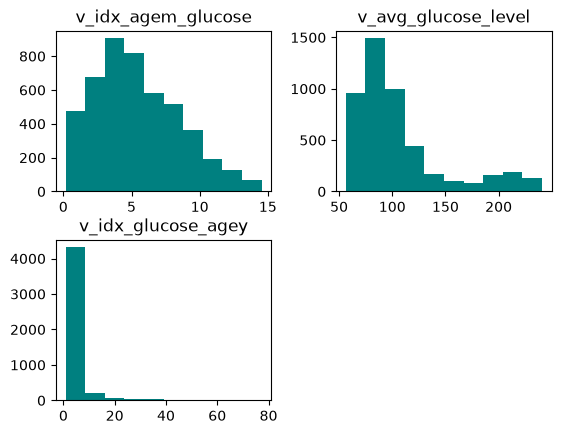

In [621]:
df[v_].hist(
    color='#008080',
    grid=False
)

## Preparación WoE
Se va a discretizar las variables numéricas. Es decir, se convierte de número a categoría para que todo esté en categórico y luego ya usar la transformación que realiza WoE para utilizar variables asociadas con la variable respuesta.

### Discretizar

In [640]:

%%time
for c in v_:
    print("Discretizando columna: ",c)
    for k in range(2,7): ## Los bines se trabajan de manera iterativa aquí van de 2 a 6
        df = discretizar( df, c , k )

Discretizando columna:  v_idx_agem_glucose
Discretizando columna:  v_avg_glucose_level
Discretizando columna:  v_idx_glucose_agey
CPU times: user 810 ms, sys: 30.4 ms, total: 841 ms
Wall time: 942 ms


In [642]:
df.sample(n=10, random_state=787)

,id,c_gender,v_age_years,c_hypertension,c_heart_disease,c_ever_married,c_work_type,c_Residence_type,v_avg_glucose_level,v_bmi,...,d_v_avg_glucose_level_2,d_v_avg_glucose_level_3,d_v_avg_glucose_level_4,d_v_avg_glucose_level_5,d_v_avg_glucose_level_6,d_v_idx_glucose_agey_2,d_v_idx_glucose_agey_3,d_v_idx_glucose_agey_4,d_v_idx_glucose_agey_5,d_v_idx_glucose_agey_6
4246,50804,Male,2.00,0,0,No,children,Rural,65.84,16.10,...,"(56.369, 92.11]","(56.369, 82.39]","(56.369, 77.79]","(56.369, 74.54]","(56.369, 72.49]","(2.431, 77.28]","(3.254, 77.28]","(3.901, 77.28]","(4.468, 77.28]","(5.129, 77.28]"
2992,53141,Female,25.00,0,0,No,Private,Rural,67.73,22.60,...,"(56.369, 92.11]","(56.369, 82.39]","(56.369, 77.79]","(56.369, 74.54]","(56.369, 72.49]","(2.431, 77.28]","(1.843, 3.254]","(2.431, 3.901]","(2.055, 2.873]","(2.431, 3.254]"
3383,8983,Female,80.00,1,0,Yes,Private,Urban,89.16,24.00,...,"(56.369, 92.11]","(82.39, 104.51]","(77.79, 92.11]","(86.0, 99.0]","(82.39, 92.11]","(0.824, 2.431]","(0.824, 1.843]","(0.824, 1.597]","(0.824, 1.461]","(0.824, 1.384]"
603,61013,Male,52.00,0,0,No,Private,Rural,69.37,36.20,...,"(56.369, 92.11]","(56.369, 82.39]","(56.369, 77.79]","(56.369, 74.54]","(56.369, 72.49]","(0.824, 2.431]","(0.824, 1.843]","(0.824, 1.597]","(0.824, 1.461]","(0.824, 1.384]"
185,35578,Male,78.00,0,0,No,Self-employed,Urban,90.19,26.90,...,"(56.369, 92.11]","(82.39, 104.51]","(77.79, 92.11]","(86.0, 99.0]","(82.39, 92.11]","(0.824, 2.431]","(0.824, 1.843]","(0.824, 1.597]","(0.824, 1.461]","(0.824, 1.384]"
90,4639,Female,69.00,0,0,Yes,Govt_job,Urban,82.81,28.00,...,"(56.369, 92.11]","(82.39, 104.51]","(77.79, 92.11]","(74.54, 86.0]","(82.39, 92.11]","(0.824, 2.431]","(0.824, 1.843]","(0.824, 1.597]","(0.824, 1.461]","(0.824, 1.384]"
3054,46434,Male,52.00,1,0,Yes,Govt_job,Urban,214.43,39.90,...,"(92.11, 240.69]","(104.51, 240.69]","(113.68, 240.69]","(123.47, 240.69]","(134.33, 240.69]","(2.431, 77.28]","(3.254, 77.28]","(3.901, 77.28]","(2.873, 4.468]","(3.254, 5.129]"
881,5694,Male,21.00,0,0,No,Private,Rural,102.05,29.90,...,"(92.11, 240.69]","(82.39, 104.51]","(92.11, 113.68]","(99.0, 123.47]","(92.11, 104.51]","(2.431, 77.28]","(3.254, 77.28]","(3.901, 77.28]","(4.468, 77.28]","(3.254, 5.129]"
4706,56799,Male,76.00,0,0,Yes,Govt_job,Urban,82.35,38.90,...,"(56.369, 92.11]","(56.369, 82.39]","(77.79, 92.11]","(74.54, 86.0]","(72.49, 82.39]","(0.824, 2.431]","(0.824, 1.843]","(0.824, 1.597]","(0.824, 1.461]","(0.824, 1.384]"
2787,46171,Male,28.00,0,0,Yes,Private,Urban,109.85,27.90,...,"(92.11, 240.69]","(104.51, 240.69]","(92.11, 113.68]","(99.0, 123.47]","(104.51, 134.33]","(2.431, 77.28]","(3.254, 77.28]","(3.901, 77.28]","(2.873, 4.468]","(3.254, 5.129]"


In [644]:
d_ = df.filter(like='d_').columns.tolist()

d_

['d_v_idx_agem_glucose_2',
 'd_v_idx_agem_glucose_3',
 'd_v_idx_agem_glucose_4',
 'd_v_idx_agem_glucose_5',
 'd_v_idx_agem_glucose_6',
 'd_v_avg_glucose_level_2',
 'd_v_avg_glucose_level_3',
 'd_v_avg_glucose_level_4',
 'd_v_avg_glucose_level_5',
 'd_v_avg_glucose_level_6',
 'd_v_idx_glucose_agey_2',
 'd_v_idx_glucose_agey_3',
 'd_v_idx_glucose_agey_4',
 'd_v_idx_glucose_agey_5',
 'd_v_idx_glucose_agey_6']

## Particion de Entrenamiento

In [663]:
mejores_ = d_+c_

In [664]:
Xt, Xv, yt, yv = train_test_split( df[mejores_+um_], df[um_+y_], train_size=0.7 , random_state=787)

In [665]:
Xt.shape , yt.shape, Xv.shape, yv.shape

((3306, 23), (3306, 2), (1417, 23), (1417, 2))

In [666]:
Xt = Xt.merge( yt, on=um_ , how='inner'  ).reset_index(drop=True)

### Mapa WoE

In [667]:
mapa_woe = list( map( lambda v: clasificacion_woe( Xt , v , y_ , um_) , mejores_ ) )

mapa_woe

[('d_v_idx_agem_glucose_2',
  {'(0.16, 4.935]': 0.2941009784336303,
   '(4.935, 14.539]': -0.23695289510783202}),
 ('d_v_idx_agem_glucose_3',
  {'(0.16, 3.688]': 0.9214409578504709,
   '(3.688, 6.51]': -0.1335907450891512,
   '(6.51, 14.539]': -0.4092683371654139}),
 ('d_v_idx_agem_glucose_4',
  {'(0.16, 3.076]': 3.0148259323695705,
   '(3.076, 4.935]': -0.4128069679062126,
   '(4.935, 7.515]': 0.11439119647478516,
   '(7.515, 14.539]': -0.5094878309243308}),
 ('d_v_idx_agem_glucose_5',
  {'(0.16, 2.686]': 3.492483411166755,
   '(2.686, 4.177]': -0.258314138693196,
   '(4.177, 5.84]': 0.13931561342331725,
   '(5.84, 8.214]': -0.09450728935573449,
   '(8.214, 14.539]': -0.6125974931634793}),
 ('d_v_idx_agem_glucose_6',
  {'(0.16, 2.34]': 3.309575172044444,
   '(2.34, 3.688]': 0.23892202831066411,
   '(3.688, 4.935]': -0.38963534774545866,
   '(4.935, 6.51]': 0.2014527397657143,
   '(6.51, 8.672]': -0.11670788234348196,
   '(8.672, 14.539]': -0.646846246972155}),
 ('d_v_avg_glucose_level

In [668]:
for v, mapa in mapa_woe:
    Xt[f'w_{v}'] = Xt[v].replace(mapa)
    Xv[f'w_{v}'] = Xv[v].replace(mapa)

In [669]:
w_ = Xt.filter(like='w_').columns.tolist()

# TAD

In [673]:
X = pd.concat([Xt,Xv],ignore_index=True)
y = pd.concat([yt,yv],ignore_index=True)

In [674]:
X.shape, y.shape

((4723, 46), (4723, 2))

In [675]:
tad = X[um_+w_].merge( y , on = um_ , how='inner').reset_index(drop=True)

In [676]:
tad

,id,w_d_v_idx_agem_glucose_2,w_d_v_idx_agem_glucose_3,w_d_v_idx_agem_glucose_4,w_d_v_idx_agem_glucose_5,w_d_v_idx_agem_glucose_6,w_d_v_avg_glucose_level_2,w_d_v_avg_glucose_level_3,w_d_v_avg_glucose_level_4,w_d_v_avg_glucose_level_5,...,w_d_v_idx_glucose_agey_5,w_d_v_idx_glucose_agey_6,w_c_gender,w_c_hypertension,w_c_heart_disease,w_c_ever_married,w_c_work_type,w_c_Residence_type,w_c_smoking_status,y
0,24905,0.29,-0.13,-0.41,-0.26,-0.39,-0.32,-0.53,-0.64,-0.80,...,-0.26,-0.39,0.02,0.21,0.13,-0.32,0.02,-0.10,-0.47,1
1,6529,0.29,0.92,3.01,3.49,0.24,-0.32,0.41,0.13,0.30,...,3.49,0.24,0.02,0.21,0.13,1.20,0.02,-0.10,0.17,0
2,67431,-0.24,-0.41,-0.51,-0.61,-0.12,0.45,0.42,0.33,0.35,...,-0.61,-0.15,0.02,0.21,0.13,-0.32,0.02,-0.10,-0.47,0
3,20625,-0.24,-0.41,-0.51,-0.09,-0.12,0.45,0.42,0.33,0.73,...,-0.09,-0.15,-0.03,-1.10,0.13,-0.32,0.02,-0.10,-0.12,0
4,48453,-0.24,-0.13,0.11,0.14,0.20,-0.32,-0.53,-0.64,0.06,...,0.14,0.25,0.02,0.21,0.13,-0.32,0.02,-0.10,0.24,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4718,6032,0.29,-0.13,-0.41,0.14,-0.39,-0.32,-0.53,-0.64,-0.80,...,0.14,-0.39,-0.03,0.21,0.13,-0.32,-0.54,-0.10,0.24,0
4719,19675,-0.24,-0.13,0.11,-0.09,0.20,-0.32,0.41,0.13,0.06,...,-0.09,0.25,0.02,0.21,0.13,-0.32,-0.54,0.10,0.17,0
4720,247,-0.24,-0.13,0.11,0.14,0.20,0.45,0.42,0.33,0.35,...,0.14,0.25,-0.03,0.21,0.13,1.20,0.02,-0.10,0.17,0
4721,2456,-0.24,-0.41,0.11,-0.09,-0.12,-0.32,0.41,0.13,0.06,...,-0.09,-0.15,-0.03,-1.10,0.13,-0.32,-0.07,0.10,-0.12,0


In [678]:
tad[y_[0]].value_counts(1)*100

y
0   95.34
1    4.66
Name: proportion, dtype: float64

In [689]:
tad.drop(columns=um_+y_).dtypes

w_d_v_idx_agem_glucose_2     object
w_d_v_idx_agem_glucose_3     object
w_d_v_idx_agem_glucose_4     object
w_d_v_idx_agem_glucose_5     object
w_d_v_idx_agem_glucose_6     object
w_d_v_avg_glucose_level_2    object
w_d_v_avg_glucose_level_3    object
w_d_v_avg_glucose_level_4    object
w_d_v_avg_glucose_level_5    object
w_d_v_avg_glucose_level_6    object
w_d_v_idx_glucose_agey_2     object
w_d_v_idx_glucose_agey_3     object
w_d_v_idx_glucose_agey_4     object
w_d_v_idx_glucose_agey_5     object
w_d_v_idx_glucose_agey_6     object
w_c_gender                   object
w_c_hypertension             object
w_c_heart_disease            object
w_c_ever_married             object
w_c_work_type                object
w_c_Residence_type           object
w_c_smoking_status           object
dtype: object

In [694]:
to_num = [col for col in tad.columns if col not in (um_ + y_)]

tad[to_num] = tad[to_num].astype('float64')

In [695]:
tad.drop(columns=um_+y_).dtypes

w_d_v_idx_agem_glucose_2     float64
w_d_v_idx_agem_glucose_3     float64
w_d_v_idx_agem_glucose_4     float64
w_d_v_idx_agem_glucose_5     float64
w_d_v_idx_agem_glucose_6     float64
w_d_v_avg_glucose_level_2    float64
w_d_v_avg_glucose_level_3    float64
w_d_v_avg_glucose_level_4    float64
w_d_v_avg_glucose_level_5    float64
w_d_v_avg_glucose_level_6    float64
w_d_v_idx_glucose_agey_2     float64
w_d_v_idx_glucose_agey_3     float64
w_d_v_idx_glucose_agey_4     float64
w_d_v_idx_glucose_agey_5     float64
w_d_v_idx_glucose_agey_6     float64
w_c_gender                   float64
w_c_hypertension             float64
w_c_heart_disease            float64
w_c_ever_married             float64
w_c_work_type                float64
w_c_Residence_type           float64
w_c_smoking_status           float64
dtype: object

## Exportar TAD

In [699]:
tad.to_parquet('Bases/CANEDO_BELTRAN_BRAULIO_P02.parquet',
               engine = 'fastparquet')

# Visualización TAD Final

## Histograma de las Variables

ValueError: supplied range of [-0.03213742523881441, inf] is not finite

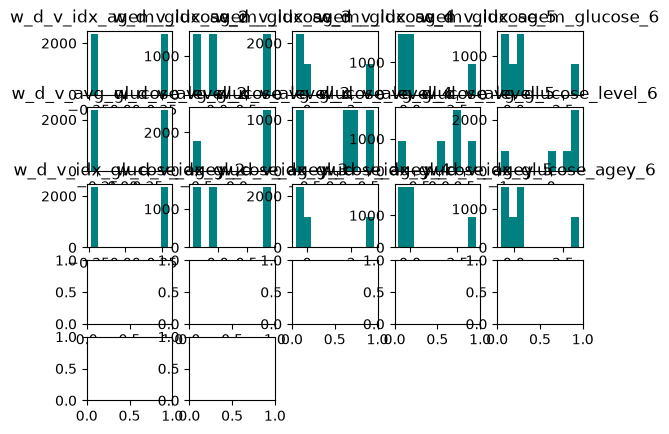

In [697]:
tad[to_num].hist(
    color='#008080',
    grid=False
)

## Visualizar TAD

In [698]:
tad

,id,w_d_v_idx_agem_glucose_2,w_d_v_idx_agem_glucose_3,w_d_v_idx_agem_glucose_4,w_d_v_idx_agem_glucose_5,w_d_v_idx_agem_glucose_6,w_d_v_avg_glucose_level_2,w_d_v_avg_glucose_level_3,w_d_v_avg_glucose_level_4,w_d_v_avg_glucose_level_5,...,w_d_v_idx_glucose_agey_5,w_d_v_idx_glucose_agey_6,w_c_gender,w_c_hypertension,w_c_heart_disease,w_c_ever_married,w_c_work_type,w_c_Residence_type,w_c_smoking_status,y
0,24905,0.29,-0.13,-0.41,-0.26,-0.39,-0.32,-0.53,-0.64,-0.80,...,-0.26,-0.39,0.02,0.21,0.13,-0.32,0.02,-0.10,-0.47,1
1,6529,0.29,0.92,3.01,3.49,0.24,-0.32,0.41,0.13,0.30,...,3.49,0.24,0.02,0.21,0.13,1.20,0.02,-0.10,0.17,0
2,67431,-0.24,-0.41,-0.51,-0.61,-0.12,0.45,0.42,0.33,0.35,...,-0.61,-0.15,0.02,0.21,0.13,-0.32,0.02,-0.10,-0.47,0
3,20625,-0.24,-0.41,-0.51,-0.09,-0.12,0.45,0.42,0.33,0.73,...,-0.09,-0.15,-0.03,-1.10,0.13,-0.32,0.02,-0.10,-0.12,0
4,48453,-0.24,-0.13,0.11,0.14,0.20,-0.32,-0.53,-0.64,0.06,...,0.14,0.25,0.02,0.21,0.13,-0.32,0.02,-0.10,0.24,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4718,6032,0.29,-0.13,-0.41,0.14,-0.39,-0.32,-0.53,-0.64,-0.80,...,0.14,-0.39,-0.03,0.21,0.13,-0.32,-0.54,-0.10,0.24,0
4719,19675,-0.24,-0.13,0.11,-0.09,0.20,-0.32,0.41,0.13,0.06,...,-0.09,0.25,0.02,0.21,0.13,-0.32,-0.54,0.10,0.17,0
4720,247,-0.24,-0.13,0.11,0.14,0.20,0.45,0.42,0.33,0.35,...,0.14,0.25,-0.03,0.21,0.13,1.20,0.02,-0.10,0.17,0
4721,2456,-0.24,-0.41,0.11,-0.09,-0.12,-0.32,0.41,0.13,0.06,...,-0.09,-0.15,-0.03,-1.10,0.13,-0.32,-0.07,0.10,-0.12,0
